# Autoencoder I: Training a CNN

## General configuration

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchsummary import summary

import xarray as xr
import matplotlib.pyplot as plt

In [51]:
### Configuration ###
BATCH_SIZE    = 12
LATENT_DIM    = 2
LEARNING_RATE = 1E-3
NUM_EPOCHS    = 150
RANDOM_SEED   = 43
FNAME_MODEL   = 'autoencoder.pt'

In [31]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for batch in loader:
        optimizer.zero_grad()
        prediction = model(batch)
        loss = criterion(prediction,batch)
        loss.backward()
        optimizer.step()
        
        # Get current batch size
        current_batch_size = batch.size(0)
        total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

In [32]:
def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            prediction = model(batch)
            loss = criterion(prediction,batch)

            # Get current batch size
            current_batch_size = batch.size(0)
            total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

### 1. Loading raw data and normalization

In [33]:
fname = 'data/tephra_col_mass.nc'
ds = xr.open_dataset(fname)
da = ds["tephra_col_mass"]

#### Standardization
Transformation so data is centered around 0 with variance ≈ 1:

$ x' = \dfrac{x-\mu}{\sigma + \epsilon}$

Choose `ε ~ 1e-6` or smaller, just to avoid division by zero

#### Simple scaling
Simple transformation resulting in positive values:

$ x' = \dfrac{x-x_{min}}{x_{max}-x_{min}}$

where $x_{min}$ are $x_{max}$ are global minimum and maximum values

In [34]:
from helper import MinMaxScale
transform = MinMaxScale(0, 25)

### 2. Create a custom Dataset and splitting

* Training dataset: Used to optimize the model parameters (learn weights)
* Validation dataset: Used during training to monitor performance (used for hyperparameter tuning, early stopping, etc...)
* Test dataset: Used once to evaluate the final chosen model for a fair (unbiased) reporting of model performance

In [57]:
from helper import EnsembleDataset
dataset = EnsembleDataset(da, transform)

# Random split with in training and validation datasets
n_total = len(dataset)
n_train = int(0.8 * n_total)   # 80% train
n_val   = n_total - n_train    # 20% val

torch.manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(dataset, [n_train, n_val])

### 3. Create a DataLoader
While training a model, we typically want to pass samples in "minibatches". `DataLoader` is an iterable that abstracts this complexity for us in an easy API:

In [58]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [60]:
for batch in train_loader:
    print(batch[0].shape)
    print(batch[1].max())
    break

torch.Size([1, 101, 121])
tensor(1.2209)


### 4. Define a model

Formula for output dims calculation in a Conv2d layer:

$ n_{out} = \lfloor \dfrac{n_{in} + 2p - k}{s} \rfloor + 1$

* k: convolution kernel size
* p: convolution padding size
* s: convolution stride size

In [38]:
from helper import Autoencoder
model = Autoencoder(LATENT_DIM)
summary(model, (1,101,121))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 51, 61]             160
              ReLU-2           [-1, 16, 51, 61]               0
            Conv2d-3           [-1, 32, 26, 31]           4,640
              ReLU-4           [-1, 32, 26, 31]               0
            Conv2d-5           [-1, 64, 13, 16]          18,496
              ReLU-6           [-1, 64, 13, 16]               0
           Flatten-7                [-1, 13312]               0
            Linear-8                    [-1, 2]          26,626
            Linear-9                [-1, 13312]          39,936
             ReLU-10                [-1, 13312]               0
        Unflatten-11           [-1, 64, 13, 16]               0
  ConvTranspose2d-12           [-1, 32, 26, 31]          18,464
             ReLU-13           [-1, 32, 26, 31]               0
  ConvTranspose2d-14           [-1, 16,

## 5. Loss function
Creates a criterion that measures the mean squared error:

In [39]:
criterion = nn.MSELoss(reduction="mean")

## 6. Optimizer

In [40]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training loop

In [41]:
train_losses = []
val_losses = []
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss   = evaluate_epoch(model, val_loader, criterion)
    # Store current losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch%10 == 0 or epoch == NUM_EPOCHS-1:
        print(f"Epoch {epoch+1:02d} -> Train loss {train_loss:.4f} | Test loss: {val_loss:.4f}")

Epoch 01 -> Train loss 0.0690 | Test loss: 0.0562
Epoch 11 -> Train loss 0.0050 | Test loss: 0.0056
Epoch 21 -> Train loss 0.0040 | Test loss: 0.0047
Epoch 31 -> Train loss 0.0038 | Test loss: 0.0054
Epoch 41 -> Train loss 0.0035 | Test loss: 0.0047
Epoch 51 -> Train loss 0.0033 | Test loss: 0.0041
Epoch 61 -> Train loss 0.0032 | Test loss: 0.0039
Epoch 71 -> Train loss 0.0030 | Test loss: 0.0037
Epoch 81 -> Train loss 0.0030 | Test loss: 0.0035
Epoch 91 -> Train loss 0.0026 | Test loss: 0.0033
Epoch 101 -> Train loss 0.0025 | Test loss: 0.0034
Epoch 111 -> Train loss 0.0023 | Test loss: 0.0032
Epoch 121 -> Train loss 0.0024 | Test loss: 0.0033
Epoch 131 -> Train loss 0.0023 | Test loss: 0.0032
Epoch 141 -> Train loss 0.0022 | Test loss: 0.0032
Epoch 150 -> Train loss 0.0022 | Test loss: 0.0032


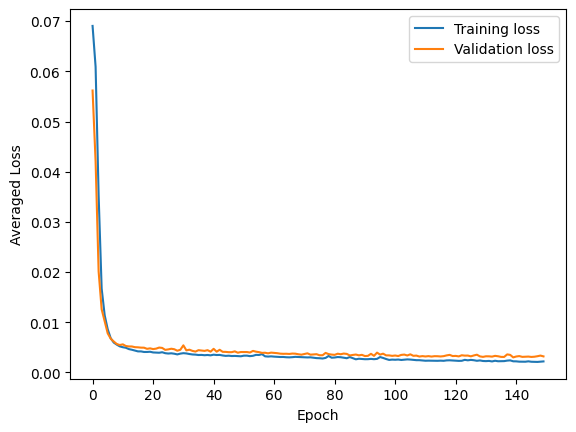

In [42]:
plt.plot(train_losses, label = 'Training loss')
plt.plot(val_losses, label = 'Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Averaged Loss')
plt.legend()

## Save trained model

In [43]:
torch.save(model.state_dict(), FNAME_MODEL)